/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/usr/local/l

Epoch 1: train=0.0107, val=0.0151
Epoch 2: train=0.0124, val=0.0082
Epoch 3: train=0.0077, val=0.0073
Epoch 4: train=0.0068, val=0.0068
Epoch 5: train=0.0061, val=0.0060
Epoch 6: train=0.0057, val=0.0056
Epoch 7: train=0.0053, val=0.0055
Epoch 8: train=0.0052, val=0.0052
Epoch 9: train=0.0051, val=0.0052
Epoch 10: train=0.0051, val=0.0051
Epoch 11: train=0.0051, val=0.0051
Epoch 12: train=0.0048, val=0.0054
Epoch 13: train=0.0048, val=0.0049
Epoch 14: train=0.0048, val=0.0049
Epoch 15: train=0.0048, val=0.0049
Epoch 16: train=0.0046, val=0.0049
Epoch 17: train=0.0047, val=0.0049
Epoch 18: train=0.0045, val=0.0049
Epoch 19: train=0.0046, val=0.0053
Epoch 20: train=0.0045, val=0.0049
Epoch 21: train=0.0043, val=0.0051
Epoch 22: train=0.0043, val=0.0052
Epoch 23: train=0.0041, val=0.0050
Epoch 24: train=0.0041, val=0.0050
Epoch 25: train=0.0040, val=0.0052
Epoch 26: train=0.0040, val=0.0058
Epoch 27: train=0.0040, val=0.0050
Epoch 28: train=0.0039, val=0.0055
Epoch 29: train=0.0039, val=0

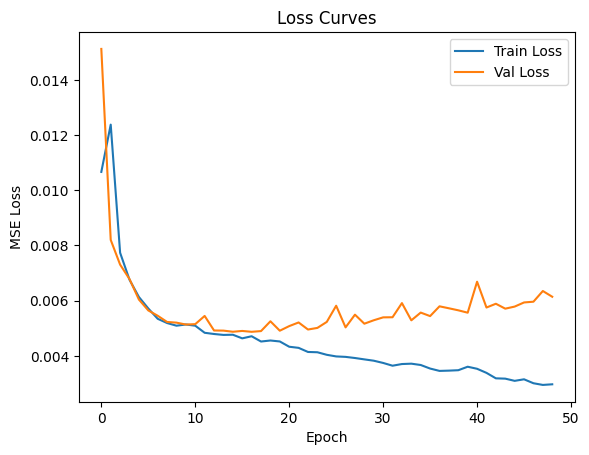

Test RMSE: 0.293


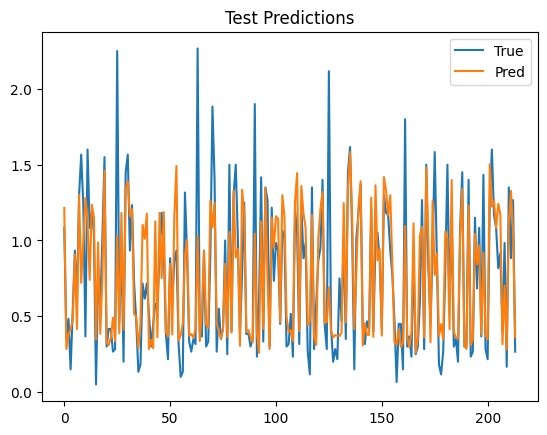

Causal features and lags:
FP_A_Count lag 1
FP_A_Count lag 2
FP_A_Count lag 3
FP_A_Count lag 4
FP_A_Count lag 5
FP_A_Count lag 6
FP_A_Count lag 7
FP_A_Count lag 8
FP_A_Count lag 9
FP_A_Count lag 10
FP_A_QueuePct lag 1
FP_A_QueuePct lag 2
FP_A_Speed lag 1
FP_A_Speed lag 2
FP_A_Speed lag 3
FP_A_Speed lag 4
FP_A_Speed lag 5
FP_A_Speed lag 6
FP_A_Speed lag 7
FP_A_Speed lag 8
FP_A_Speed lag 9
FP_A_Speed lag 10
FP_B_Count lag 1
FP_B_Count lag 2
FP_B_Count lag 3
FP_B_Count lag 4
FP_B_Count lag 5
FP_B_Count lag 6
FP_B_Count lag 7
FP_B_Count lag 8
FP_B_Count lag 9
FP_B_Count lag 10
FP_B_QueuePct lag 1
FP_B_QueuePct lag 2
FP_B_QueuePct lag 3
FP_B_QueuePct lag 4
FP_B_QueuePct lag 5
FP_B_QueuePct lag 6
FP_B_QueuePct lag 7
FP_B_QueuePct lag 8
FP_B_QueuePct lag 9
FP_B_QueuePct lag 10
FP_B_Speed lag 1
FP_B_Speed lag 2
FP_B_Speed lag 3
FP_B_Speed lag 4
FP_B_Speed lag 5
FP_B_Speed lag 6
FP_B_Speed lag 7
FP_B_Speed lag 8
FP_B_Speed lag 9
FP_B_Speed lag 10
FP_C_Count lag 1
FP_C_Count lag 2
FP_C_Count lag 

In [ ]:
import pandas as pd
import numpy as np
import warnings
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from scipy import optimize
import matplotlib.pyplot as plt

# suppress warnings
warnings.filterwarnings('ignore', message='verbose is deprecated')
warnings.filterwarnings('ignore', category=FutureWarning)

# 1. Load and downsample data
file_path = "junction_data_race_course.csv"
df = pd.read_csv(file_path)
N = 60  # average per 60 rows: per-second -> per-minute
df['bin'] = (np.arange(len(df)) // N)
df = df.groupby('bin').mean().reset_index(drop=True)

# 2. Causality-based feature selection
MAX_LAG = 10
causal_pairs = []
for col in df.columns.drop("FP_D_Count"):
    data = df[["FP_D_Count", col]].dropna()
    results = grangercausalitytests(data, maxlag=MAX_LAG, verbose=False)
    for lag, res in results.items():
        if res[0]["ssr_ftest"][1] < 0.05:
            causal_pairs.append((col, lag))

# Build lagged features
df_lags = []
feature_cols = []
for col, lag in causal_pairs:
    lag_col = f"{col}_lag{lag}"
    df_lags.append(df[col].shift(lag).rename(lag_col))
    feature_cols.append(lag_col)

df = pd.concat([df] + df_lags, axis=1)
df = df.dropna(subset=feature_cols + ["FP_D_Count"]).reset_index(drop=True)

# 3. Normalize
feat_scaler = MinMaxScaler()
tgt_scaler = MinMaxScaler()
X_all = feat_scaler.fit_transform(df[feature_cols])
y_all = tgt_scaler.fit_transform(df[["FP_D_Count"]])

# 4. Sliding-window
SEQ_LEN = 10
Xs, ys = [], []
for i in range(len(X_all) - SEQ_LEN):
    Xs.append(X_all[i:i+SEQ_LEN])
    ys.append(y_all[i+SEQ_LEN])
Xs = np.array(Xs)
ys = np.array(ys)

# 5. Dataset & splits
class JunctionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

dataset = JunctionDataset(Xs, ys)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
test_loader = DataLoader(test_ds, batch_size=64)

# 6. p-Elliott activation & fixed-point
from scipy.optimize import fixed_point
class PElliott(nn.Module):
    def __init__(self, alpha_init=1.0):
        super().__init__()
        self.alpha = nn.Parameter(torch.tensor(alpha_init))
    def forward(self, x):
        return self.alpha * x / (1 + x.abs())
    def refine(self, x0):
        a0 = float(self.alpha)
        x_scalar = float(np.mean(x0))
        a_new = fixed_point(lambda a: (0.5*x_scalar*a)/(1+abs(x_scalar*a))+0.5, a0, xtol=1e-4, maxiter=50)
        with torch.no_grad(): self.alpha.copy_(torch.tensor(a_new))

class PLSTMCell(nn.Module):
    def __init__(self, in_size, h_size):
        super().__init__(); self.h = h_size
        self.W = nn.Linear(in_size+h_size, 4*h_size)
        self.p = PElliott()
    def forward(self, x, hx):
        h_prev, c_prev = hx
        i,f,o,g = self.W(torch.cat([x,h_prev],1)).chunk(4,1)
        i,f,o = self.p(i), self.p(f), self.p(o)
        g = torch.tanh(g)
        c = f*c_prev + i*g; h = o*torch.tanh(c)
        return h,c

class PLSTM(nn.Module):
    def __init__(self, in_size, h_size, layers=1):
        super().__init__();
        self.cells = nn.ModuleList([PLSTMCell(in_size if i==0 else h_size, h_size) for i in range(layers)])
        self.fc = nn.Linear(h_size,1)
    def forward(self, x):
        b,seq,_ = x.size()
        h = [torch.zeros(b,c.h,device=x.device) for c in self.cells]
        c = [torch.zeros_like(hl) for hl in h]
        for t in range(seq):
            inp = x[:,t,:]
            for j,cell in enumerate(self.cells): h[j],c[j] = cell(inp,(h[j],c[j])); inp=h[j]
        return self.fc(h[-1])
    def refine_all(self, xb):
        xs = xb.cpu().numpy(); rep = xs.mean()
        for c in self.cells: c.p.refine(rep)

# 7. Train with validation tracking
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PLSTM(Xs.shape[2],32).to(device)
opt = torch.optim.Adam(model.parameters(),1e-3); loss_fn=nn.MSELoss()
hist = {'train':[], 'val':[]}
for epoch in range(1,50):
    model.train(); train_loss=0
    for Xb,yb in train_loader:
        Xb,yb = Xb.to(device), yb.to(device)
        opt.zero_grad(); pred=model(Xb); loss=loss_fn(pred,yb); loss.backward(); opt.step()
        train_loss+=loss.item()*Xb.size(0)
    model.refine_all(Xb[:,-1,:])
    train_loss/=len(train_loader.dataset)
    model.eval(); val_loss=0
    with torch.no_grad():
        for Xv,yv in val_loader:
            Xv,yv=Xv.to(device),yv.to(device)
            val_loss+=loss_fn(model(Xv),yv).item()*Xv.size(0)
    val_loss/=len(val_loader.dataset)
    hist['train'].append(train_loss); hist['val'].append(val_loss)
    print(f"Epoch {epoch}: train={train_loss:.4f}, val={val_loss:.4f}")

# 8. Plot training & validation loss
plt.figure(); plt.plot(hist['train'], label='Train Loss'); plt.plot(hist['val'], label='Val Loss');
plt.title('Loss Curves'); plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.legend(); plt.show()

# 9. Test performance & plot
model.eval(); test_pred, test_true = [], []
with torch.no_grad():
    for Xt,yt in test_loader:
        Xt,yt = Xt.to(device), yt.to(device)
        pr = model(Xt).cpu().numpy(); test_pred.append(pr); test_true.append(yt.cpu().numpy())
test_pred = np.vstack(test_pred); test_true = np.vstack(test_true)
test_pred_o = tgt_scaler.inverse_transform(test_pred); test_true_o = tgt_scaler.inverse_transform(test_true)
print(f"Test RMSE: {np.sqrt(mean_squared_error(test_true_o, test_pred_o)):.3f}")
plt.figure(); plt.plot(test_true_o, label='True'); plt.plot(test_pred_o, label='Pred'); plt.title('Test Predictions'); plt.legend(); plt.show()

# 10. Causality summary
print("Causal features and lags:")
for col,lag in causal_pairs: print(f"{col} lag {lag}")

Test RMSE: 0.293


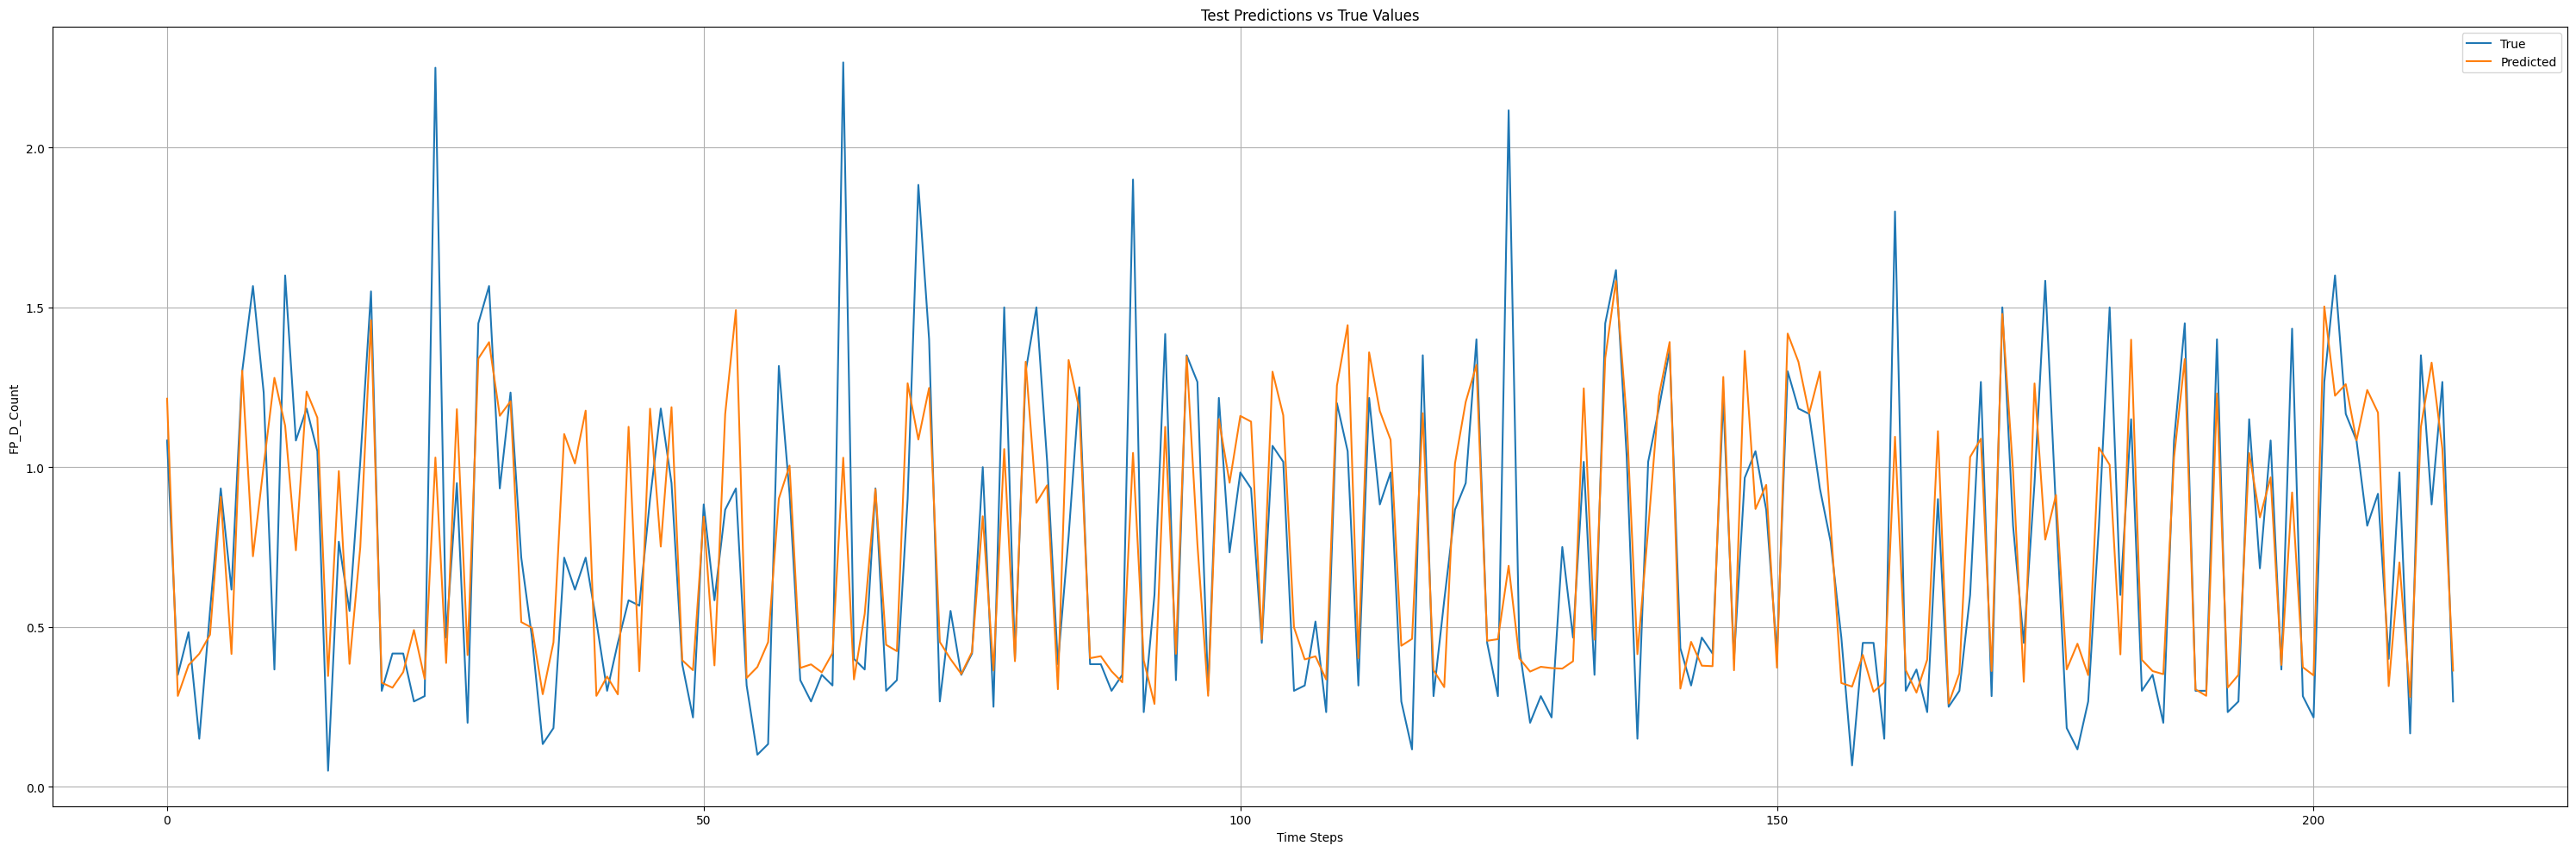

In [ ]:
# --- Test Performance Evaluation and Plotting ---

# Set model to evaluation mode
model.eval()

# Containers for predictions and true values
test_pred = []
test_true = []

# Disable gradient tracking for evaluation
with torch.no_grad():
    for Xt, yt in test_loader:
        Xt, yt = Xt.to(device), yt.to(device)
        pr = model(Xt).cpu().numpy()
        test_pred.append(pr)
        test_true.append(yt.cpu().numpy())

# Concatenate all batches
test_pred = np.vstack(test_pred)
test_true = np.vstack(test_true)

# Inverse transform to get predictions in original scale
test_pred_o = tgt_scaler.inverse_transform(test_pred)
test_true_o = tgt_scaler.inverse_transform(test_true)

# Calculate and print RMSE
test_rmse = np.sqrt(mean_squared_error(test_true_o, test_pred_o))
print(f"Test RMSE: {test_rmse:.3f}")

# Plot the results
plt.figure(figsize=(30, 10))
plt.plot(test_true_o, label='True')
plt.plot(test_pred_o, label='Predicted')
plt.title('Test Predictions vs True Values')
plt.xlabel('Time Steps')
plt.ylabel('FP_D_Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/usr/local/l

Epoch 1: train=0.2147, val=0.1278
Epoch 2: train=0.0904, val=0.0770
Epoch 3: train=0.0820, val=0.0728
Epoch 4: train=0.0767, val=0.0748
Epoch 5: train=0.0742, val=0.0725
Epoch 6: train=0.0741, val=0.0722
Epoch 7: train=0.0730, val=0.0743
Epoch 8: train=0.0736, val=0.0706
Epoch 9: train=0.0678, val=0.0810
Epoch 10: train=0.0673, val=0.0761
Epoch 11: train=0.0686, val=0.0713
Epoch 12: train=0.0664, val=0.0740
Epoch 13: train=0.0653, val=0.0717
Epoch 14: train=0.0640, val=0.0725
Epoch 15: train=0.0630, val=0.0792
Epoch 16: train=0.0619, val=0.0725
Epoch 17: train=0.0607, val=0.0779
Epoch 18: train=0.0607, val=0.0774
Epoch 19: train=0.0560, val=0.0788
Epoch 20: train=0.0559, val=0.0796
Epoch 21: train=0.0556, val=0.0805
Epoch 22: train=0.0533, val=0.0813
Epoch 23: train=0.0511, val=0.0790
Epoch 24: train=0.0508, val=0.0795
Epoch 25: train=0.0502, val=0.0835
Epoch 26: train=0.0478, val=0.0915
Epoch 27: train=0.0470, val=0.0846
Epoch 28: train=0.0451, val=0.0832
Epoch 29: train=0.0455, val=0

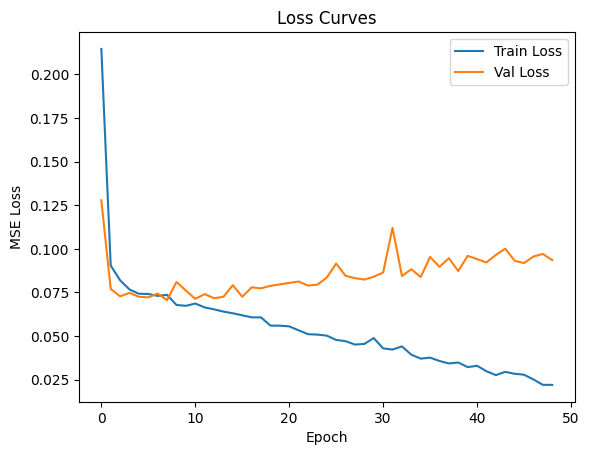

Test RMSE: 1.329


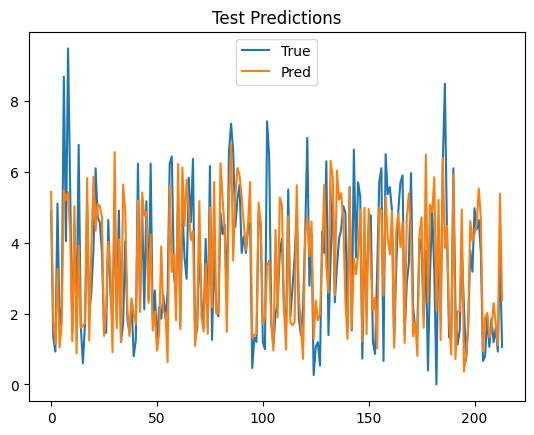

Causal features and lags:
FP_A_Count lag 1
FP_A_Count lag 2
FP_A_Count lag 3
FP_A_Count lag 4
FP_A_Count lag 5
FP_A_Count lag 6
FP_A_Count lag 7
FP_A_Count lag 8
FP_A_Count lag 9
FP_A_Count lag 10
FP_A_QueuePct lag 1
FP_A_QueuePct lag 2
FP_A_Speed lag 1
FP_A_Speed lag 2
FP_A_Speed lag 3
FP_A_Speed lag 4
FP_A_Speed lag 5
FP_A_Speed lag 6
FP_A_Speed lag 7
FP_A_Speed lag 8
FP_A_Speed lag 9
FP_A_Speed lag 10
FP_B_Count lag 1
FP_B_Count lag 2
FP_B_Count lag 3
FP_B_Count lag 4
FP_B_Count lag 5
FP_B_Count lag 6
FP_B_Count lag 7
FP_B_Count lag 8
FP_B_Count lag 9
FP_B_Count lag 10
FP_B_QueuePct lag 1
FP_B_QueuePct lag 2
FP_B_QueuePct lag 3
FP_B_QueuePct lag 4
FP_B_QueuePct lag 5
FP_B_QueuePct lag 6
FP_B_QueuePct lag 7
FP_B_QueuePct lag 8
FP_B_QueuePct lag 9
FP_B_QueuePct lag 10
FP_B_Speed lag 1
FP_B_Speed lag 2
FP_B_Speed lag 3
FP_B_Speed lag 4
FP_B_Speed lag 5
FP_B_Speed lag 6
FP_B_Speed lag 7
FP_B_Speed lag 8
FP_B_Speed lag 9
FP_B_Speed lag 10
FP_C_Count lag 1
FP_C_Count lag 2
FP_C_Count lag 

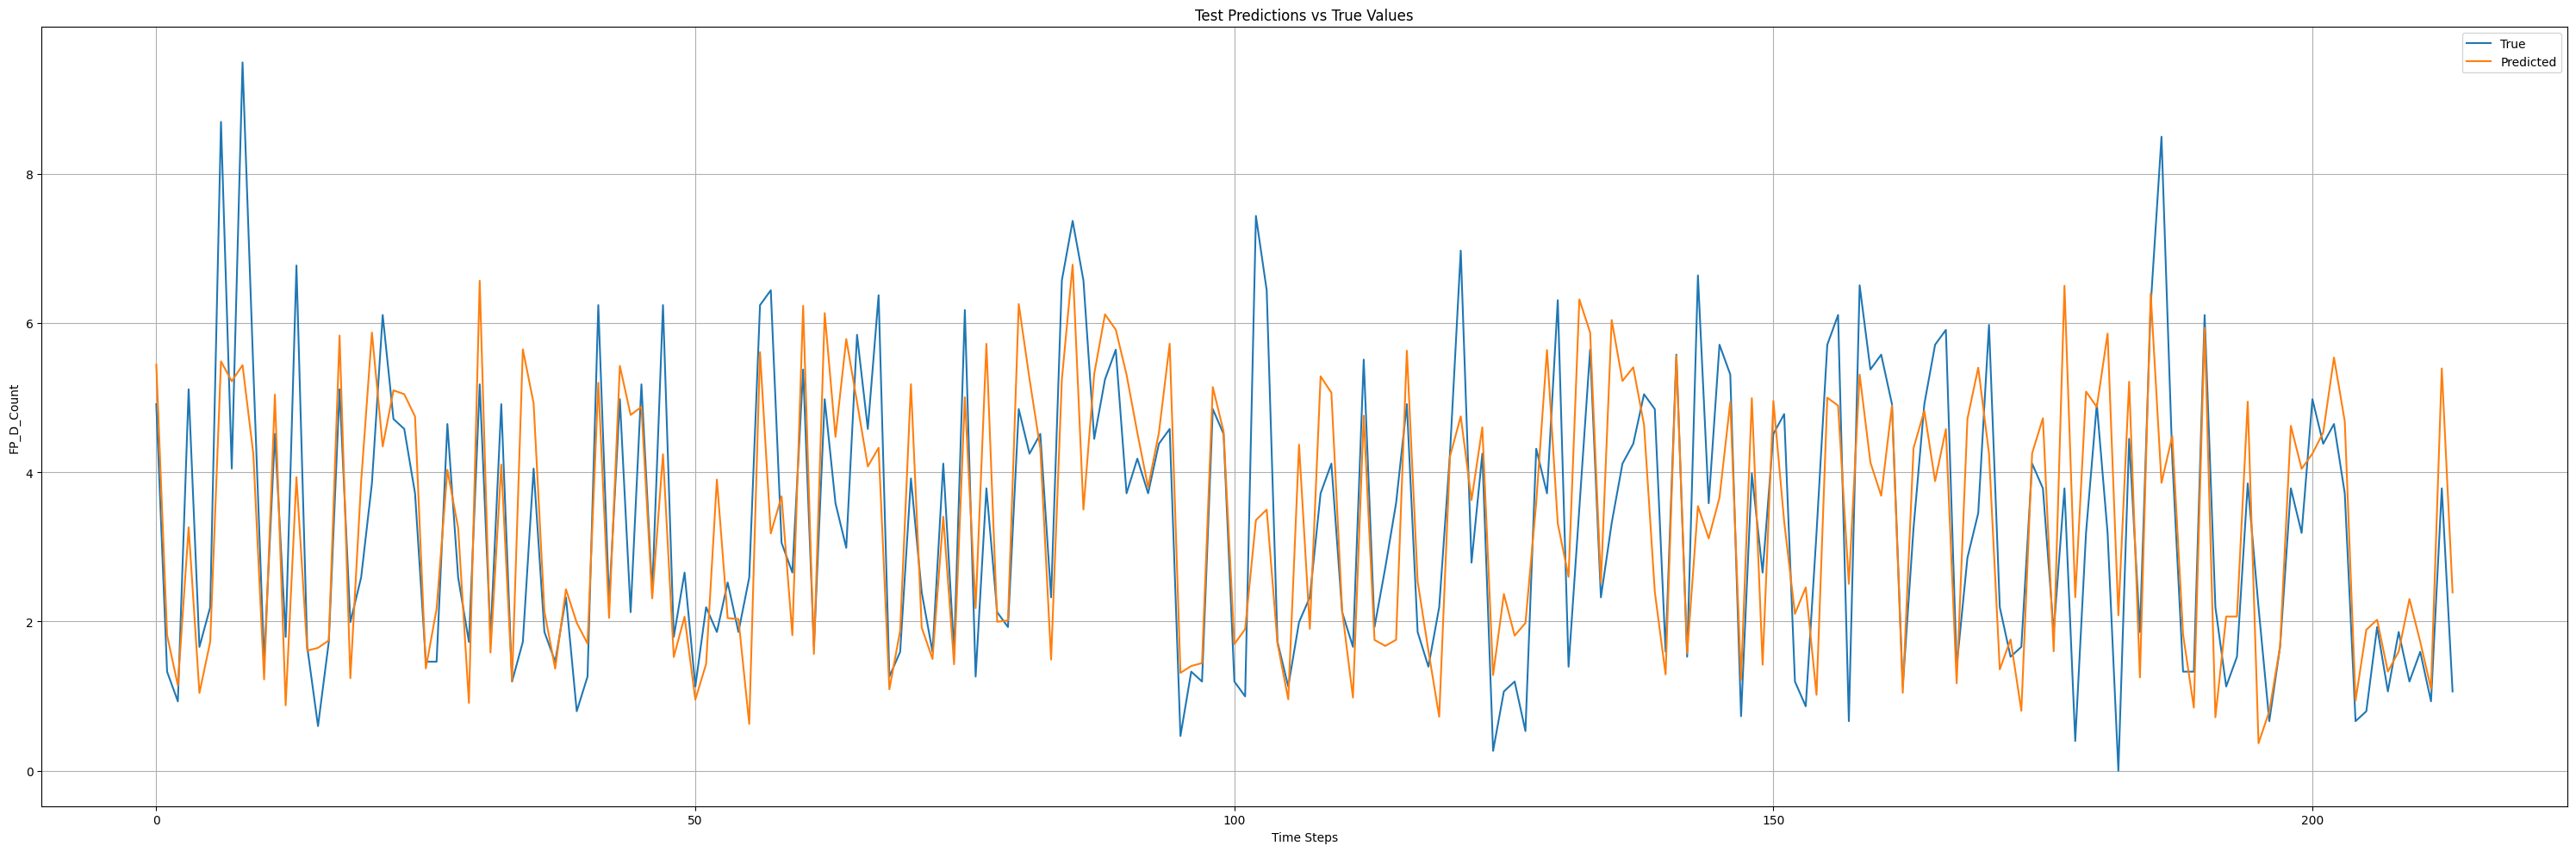

In [ ]:
import pandas as pd
import numpy as np
import warnings
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from scipy import optimize
import matplotlib.pyplot as plt

# suppress warnings
warnings.filterwarnings('ignore', message='verbose is deprecated')
warnings.filterwarnings('ignore', category=FutureWarning)

# 1. Load and downsample data
file_path = "junction_data_race_course.csv"
df = pd.read_csv(file_path)
N = 60  # average per 60 rows: per-second -> per-minute
df['bin'] = (np.arange(len(df)) // N)
df = df.groupby('bin').mean().reset_index(drop=True)

# 2. Causality-based feature selection
MAX_LAG = 10
causal_pairs = []
for col in df.columns.drop("FP_D_Count"):
    data = df[["FP_D_Count", col]].dropna()
    results = grangercausalitytests(data, maxlag=MAX_LAG, verbose=False)
    for lag, res in results.items():
        if res[0]["ssr_ftest"][1] < 0.05:
            causal_pairs.append((col, lag))

# Build lagged features
df_lags = []
feature_cols = []
for col, lag in causal_pairs:
    lag_col = f"{col}_lag{lag}"
    df_lags.append(df[col].shift(lag).rename(lag_col))
    feature_cols.append(lag_col)

df = pd.concat([df] + df_lags, axis=1)
df = df.dropna(subset=feature_cols + ["FP_D_Count"]).reset_index(drop=True)


X_all = df[feature_cols]
y_all = df[["FP_D_Count"]]

# 4. Sliding-window
SEQ_LEN = 10
Xs, ys = [], []
for i in range(len(X_all) - SEQ_LEN):
    Xs.append(X_all[i:i+SEQ_LEN])
    # Corrected to use iloc for row indexing
    ys.append(y_all.iloc[i+SEQ_LEN])
Xs = np.array(Xs)
ys = np.array(ys)

# 5. Dataset & splits
class JunctionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

dataset = JunctionDataset(Xs, ys)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
test_loader = DataLoader(test_ds, batch_size=64)

# 6. p-Elliott activation & fixed-point
from scipy.optimize import fixed_point
class PElliott(nn.Module):
    def __init__(self, alpha_init=1.0):
        super().__init__()
        self.alpha = nn.Parameter(torch.tensor(alpha_init))
    def forward(self, x):
        return self.alpha * x / (1 + x.abs())
    def refine(self, x0):
        a0 = float(self.alpha)
        x_scalar = float(np.mean(x0))
        a_new = fixed_point(lambda a: (0.5*x_scalar*a)/(1+abs(x_scalar*a))+0.5, a0, xtol=1e-4, maxiter=50)
        with torch.no_grad(): self.alpha.copy_(torch.tensor(a_new))

class PLSTMCell(nn.Module):
    def __init__(self, in_size, h_size):
        super().__init__(); self.h = h_size
        self.W = nn.Linear(in_size+h_size, 4*h_size)
        self.p = PElliott()
    def forward(self, x, hx):
        h_prev, c_prev = hx
        i,f,o,g = self.W(torch.cat([x,h_prev],1)).chunk(4,1)
        i,f,o = self.p(i), self.p(f), self.p(o)
        g = torch.tanh(g)
        c = f*c_prev + i*g; h = o*torch.tanh(c)
        return h,c

class PLSTM(nn.Module):
    def __init__(self, in_size, h_size, layers=1):
        super().__init__();
        self.cells = nn.ModuleList([PLSTMCell(in_size if i==0 else h_size, h_size) for i in range(layers)])
        self.fc = nn.Linear(h_size,1)
    def forward(self, x):
        b,seq,_ = x.size()
        h = [torch.zeros(b,c.h,device=x.device) for c in self.cells]
        c = [torch.zeros_like(hl) for hl in h]
        for t in range(seq):
            inp = x[:,t,:]
            for j,cell in enumerate(self.cells): h[j],c[j] = cell(inp,(h[j],c[j])); inp=h[j]
        return self.fc(h[-1])
    def refine_all(self, xb):
        xs = xb.cpu().numpy(); rep = xs.mean()
        for c in self.cells: c.p.refine(rep)

# 7. Train with validation tracking
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PLSTM(Xs.shape[2],32).to(device)
opt = torch.optim.Adam(model.parameters(),1e-3); loss_fn=nn.MSELoss()
hist = {'train':[], 'val':[]}
for epoch in range(1,50):
    model.train(); train_loss=0
    for Xb,yb in train_loader:
        Xb,yb = Xb.to(device), yb.to(device)
        opt.zero_grad(); pred=model(Xb); loss=loss_fn(pred,yb); loss.backward(); opt.step()
        train_loss+=loss.item()*Xb.size(0)
    model.refine_all(Xb[:,-1,:])
    train_loss/=len(train_loader.dataset)
    model.eval(); val_loss=0
    with torch.no_grad():
        for Xv,yv in val_loader:
            Xv,yv=Xv.to(device),yv.to(device)
            val_loss+=loss_fn(model(Xv),yv).item()*Xv.size(0)
    val_loss/=len(val_loader.dataset)
    hist['train'].append(train_loss); hist['val'].append(val_loss)
    print(f"Epoch {epoch}: train={train_loss:.4f}, val={val_loss:.4f}")

# 8. Plot training & validation loss
plt.figure(); plt.plot(hist['train'], label='Train Loss'); plt.plot(hist['val'], label='Val Loss');
plt.title('Loss Curves'); plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.legend(); plt.show()

# 9. Test performance & plot
model.eval(); test_pred, test_true = [], []
with torch.no_grad():
    for Xt,yt in test_loader:
        Xt,yt = Xt.to(device), yt.to(device)
        pr = model(Xt).cpu().numpy(); test_pred.append(pr); test_true.append(yt.cpu().numpy())
test_pred = np.vstack(test_pred); test_true = np.vstack(test_true)
test_pred_o = tgt_scaler.inverse_transform(test_pred); test_true_o = tgt_scaler.inverse_transform(test_true)
print(f"Test RMSE: {np.sqrt(mean_squared_error(test_true_o, test_pred_o)):.3f}")
plt.figure(); plt.plot(test_true_o, label='True'); plt.plot(test_pred_o, label='Pred'); plt.title('Test Predictions'); plt.legend(); plt.show()

# 10. Causality summary
print("Causal features and lags:")
for col,lag in causal_pairs: print(f"{col} lag {lag}")
# Set model to evaluation mode
model.eval()

# Containers for predictions and true values
test_pred = []
test_true = []

# Disable gradient tracking for evaluation
with torch.no_grad():
    for Xt, yt in test_loader:
        Xt, yt = Xt.to(device), yt.to(device)
        pr = model(Xt).cpu().numpy()
        test_pred.append(pr)
        test_true.append(yt.cpu().numpy())

# Concatenate all batches
test_pred = np.vstack(test_pred)
test_true = np.vstack(test_true)

# Inverse transform to get predictions in original scale
test_pred_o = tgt_scaler.inverse_transform(test_pred); test_true_o = tgt_scaler.inverse_transform(test_true)

# Calculate and print RMSE
test_rmse = np.sqrt(mean_squared_error(test_true_o, test_pred_o))
print(f"Test RMSE: {test_rmse:.3f}")

# Plot the results
plt.figure(figsize=(30, 10))
plt.plot(test_true_o, label='True')
plt.plot(test_pred_o, label='Predicted')
plt.title('Test Predictions vs True Values')
plt.xlabel('Time Steps')
plt.ylabel('FP_D_Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()